# gold_rate_carry — end-to-end pipeline

This notebook imports and calls the existing modules only; it adds no new analytical logic. Modules live under `src/` (import as `from src import ...`).

In [1]:
import sys, os
# make the repo root (parent of notebooks/) importable regardless of cwd
for _p in (os.getcwd(), os.path.abspath("..")):
    if os.path.isdir(os.path.join(_p, "src")) and _p not in sys.path:
        sys.path.insert(0, _p)

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

# report.py switches matplotlib to the Agg backend on import; re-enable the inline
# backend AFTER importing it so this notebook's charts display inline.
from src import loaders, audit, clean, signals, costs, backtest, evaluate, report
%matplotlib inline
import matplotlib.pyplot as plt

LOOKBACK = 20
OOS_START, OOS_END = "2017-01-01", "2025-12-31"
pd.set_option("display.width", 160)

## 1. Data Loading & Audit

This project tests whether gold's price responds to the real (inflation-adjusted)
interest rate in a way that's tradeable. Two series are needed: GLD (SPDR Gold Shares,
via yfinance) and DFII10, the 10-Year TIPS-derived real yield, obtained as a manually downloaded CSV from FRED.
DFII10 is not a tradeable instrument — it's a published Treasury/Fed statistic, not
covered by yfinance.

Both series are independently audited before use: hard errors (duplicate/non-monotonic
dates, implausible units, OHLC inconsistencies) are checked and raised immediately;
anomalies (extreme moves via a median-absolute-deviation threshold, repeated/stale
values, zero-volume days) are flagged for review, not auto-corrected. Negative DFII10
values are *not* flagged — real yields were genuinely negative for extended periods
(2011–2013, 2020–2022) and this is expected, not an error.

In [2]:
gld = loaders.fetch_gld("2004-11-01", "2026-08-07")
dfii = loaders.load_dfii10()

gld_audit = audit.audit_gld(gld)
dfii_audit = audit.audit_dfii10(dfii)

print("GLD:   ", gld.shape[0], "rows,", gld.index.min().date(), "->", gld.index.max().date())
print("  hard-error checks passed:", gld_audit["hard_errors_checked"])
print("  anomaly summary:", gld_audit["summary"])
print()
print("DFII10:", dfii.shape[0], "rows,", dfii.index.min().date(), "->", dfii.index.max().date())
print("  hard-error checks passed:", dfii_audit["hard_errors_checked"])
print("  anomaly summary:", dfii_audit["summary"])

GLD:    5462 rows, 2004-11-18 -> 2026-08-06
  hard-error checks passed: ['no_duplicate_dates', 'monotonic_increasing_dates', 'no_negative_prices', 'ohlc_consistency', 'price_units_within_bounds']
  anomaly summary: {'mad_outlier_pct_change': 57, 'stale_adj_close': 0, 'zero_volume': 0, 'close_adj_divergence': 0, 'nan_count': 0, 'n_rows': 5462}

DFII10: 6156 rows, 2003-01-02 -> 2026-08-06
  hard-error checks passed: ['no_duplicate_dates', 'monotonic_increasing_dates', 'value_units_within_bounds']
  anomaly summary: {'mad_outlier_change': 24, 'stale_value': 131, 'nan_count': 253, 'n_rows': 6156}


## 2. Data Cleaning

Two adjustments are required before the series can be merged, both about *when*
information was actually knowable, not about fixing bad data — no anomalies required
correction (see `data/decisions.md`).

**Publication-date (T+1) alignment.** FRED labels each DFII10 value by the date it
describes, not the date it was published — a value dated day T isn't actually knowable
until T+1. The series is shifted forward by one row (relative to its own date-ordered
index, so it stays correct around holidays) so any trading decision uses only what was
genuinely public by that day.

**Trading-calendar mismatch.** GLD trades on the NYSE calendar; DFII10 is published on
bond-market business days — these are not identical. The merge uses GLD's calendar as
the base. On a GLD trading day where no new DFII10 value exists (a bond-market holiday),
the last published value is forward-filled. This is not data invention: nothing occurred
to change the real yield that day, so there is no unobserved "true" value different from
the last print — only the absence of a new one. GLD itself is never forward-filled.

In [3]:
merged = clean.clean_and_merge(gld, dfii)
print("Merged shape:", merged.shape)
print("Forward-filled DFII10 rows (bond-market holidays):",
      int(merged["dfii10_forward_filled"].sum()))
merged.head()

Merged shape: (5462, 4)
Forward-filled DFII10 rows (bond-market holidays): 232


,gld_close,gld_adj_close,dfii10_aligned,dfii10_forward_filled
date,,,,
2004-11-18,44.380001,44.380001,1.63,False
2004-11-19,44.779999,44.779999,1.64,False
2004-11-22,44.950001,44.950001,1.67,False
2004-11-23,44.750000,44.750000,1.62,False
2004-11-24,45.049999,45.049999,1.65,False


## 3. Signal Construction

**Mechanism.** Gold pays no coupon, so the opportunity cost of holding it is the real
interest rate: falling real yields reduce that cost and should support gold's price.
Modeling gold as a bond with no coupon and no maturity, price ≈ 1/(1+r)^T implies price
sensitivity to r grows with T — an effectively infinite-maturity asset should be
unusually rate-sensitive (Barsky & Summers, 1988).

**Why the real yield, not nominal.** Nominal yield ≈ real yield + inflation
expectations — two effects that push gold in *opposite* directions (rising real rates →
gold down via opportunity cost; rising inflation expectations → gold up, as a hedge).
Using DFII10 nets out the inflation-expectation channel before it reaches the signal.

**Signal:** for lookback N, long GLD if DFII10 has fallen over the past N trading days,
flat otherwise. Sign only, no magnitude threshold — keeping N the single tunable
parameter in the strategy. Computed daily; the position itself only updates on each
month's first trading day (monthly rebalance), a design choice kept independent of N so
the parameter grid isolates one variable at a time (see §6 for the cost/frequency
trade-off this implies).

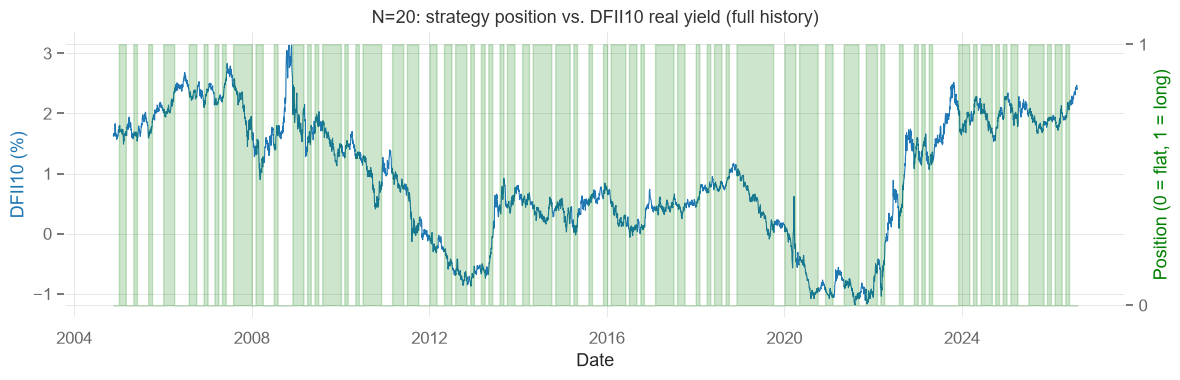

In [4]:
daily_signal = signals.compute_signal(merged, LOOKBACK)
position = signals.apply_monthly_rebalance(daily_signal, merged.index)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(merged.index, merged["dfii10_aligned"], color="#1f77b4", lw=0.8,
         label="DFII10 real yield")
ax1.set_ylabel("DFII10 (%)", color="#1f77b4"); ax1.set_xlabel("Date")
ax2 = ax1.twinx()
ax2.fill_between(position.index, 0, position.fillna(0.0), step="post",
                 color="green", alpha=0.20)
ax2.set_ylabel("Position (0 = flat, 1 = long)", color="green")
ax2.set_ylim(-0.05, 1.05); ax2.set_yticks([0, 1])
ax1.set_title(f"N={LOOKBACK}: strategy position vs. DFII10 real yield (full history)")
fig.tight_layout(); plt.show()

## 4. Backtest

The backtest engine is deliberately signal- and asset-agnostic — it takes any position
series and any price series, with no GLD- or DFII10-specific logic — so it's reusable
beyond this specific strategy. Returns are computed as `position(t-1) × return(t)`,
using yesterday's decided position against today's return, avoiding same-day lookahead.

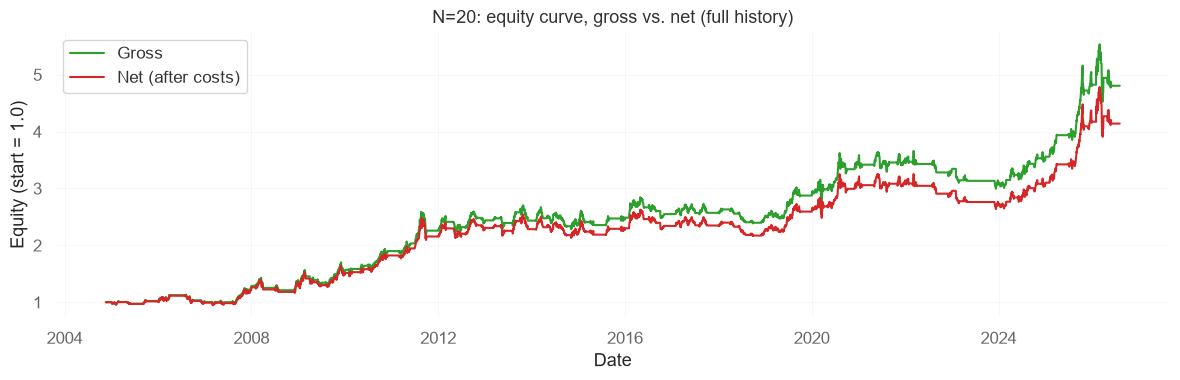

In [5]:
cost_fn = costs.build_cost_fn()   # 8 bps one-way + 0.40% annual expense ratio
result = backtest.run_backtest(merged["gld_adj_close"], position, cost_fn=cost_fn)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(result["gross_equity_curve"].index, result["gross_equity_curve"],
        color="#2ca02c", label="Gross")
ax.plot(result["equity_curve"].index, result["equity_curve"],
        color="#d62728", label="Net (after costs)")
ax.set_title(f"N={LOOKBACK}: equity curve, gross vs. net (full history)")
ax.set_ylabel("Equity (start = 1.0)"); ax.set_xlabel("Date")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 5. Costs

Two components, kept separable since they respond differently to trading frequency
versus holding duration: a per-trade cost (8 bps one-way, charged only when the position
changes) and GLD's ongoing expense ratio (0.40% annually, charged continuously while
holding, independent of trading). Gross and net returns are both reported throughout,
since cost drag materially affects whether a result is worth pursuing.

In [6]:
# cost_fn's component series are populated by the backtest call in Section 4.
txn = cost_fn.transaction_costs
exp = cost_fn.expense_ratio_costs
print(f"Transaction cost (8 bps one-way): total daily drag = {txn.sum():.4f} "
      f"over {int((txn > 0).sum())} trade days")
print(f"Expense ratio (0.40%/yr):         total daily drag = {exp.sum():.4f} "
      f"over {int((exp > 0).sum())} holding days")
pd.DataFrame(
    {"total_daily_drag": [txn.sum(), exp.sum()],
     "days_charged": [int((txn > 0).sum()), int((exp > 0).sum())]},
    index=["transaction_costs", "expense_ratio_costs"],
)

Transaction cost (8 bps one-way): total daily drag = 0.1024 over 128 trade days
Expense ratio (0.40%/yr):         total daily drag = 0.0465 over 2932 holding days


,total_daily_drag,days_charged
transaction_costs,0.10240,128
expense_ratio_costs,0.04654,2932


## 6. Robustness

**Parameter selection (in-sample only, 2005–2016).** All four candidate lookbacks
{10, 20, 40, 60} are run and reported; N=20 is selected by highest IS Sharpe, beating
473 of 500 exposure-matched random-timing draws (94.6th percentile).

**Out-of-sample confirmation (2017–2025), N=20 frozen.** No further tuning. OOS Sharpe
is positive and bootstrap-significant, but ranks only at the 36.2nd percentile against
random-timing draws with matched exposure — meaning the OOS gain is largely explained by
gold's own upward drift over the period (beta), not demonstrated timing skill.

**Regime split.** Regime 1 (2008–2021, near-zero/falling real yields): Sharpe 0.589,
beats random timing at the 98.2nd percentile — genuine, statistically supported edge.
Regime 2 (2022–2024, sharply rising real yields): Sharpe −0.043, beats random timing at
only the 8.8th percentile — the mechanism adds no value here.

**Block bootstrap significance (block = 21 trading days, matching the rebalance
cadence).** IS, OOS, and Regime 1 Sharpes are all bootstrap-distinguishable from zero
(95% CIs exclude zero). Regime 2 is not (95% CI: [−0.886, 0.878]) — with only 36 months
of data, its near-zero result cannot be distinguished from noise. Note the distinction
between the two significance checks: bootstrap tests whether Sharpe is reliably above
zero (satisfiable through beta alone); the random-timing benchmark tests whether the
*specific dates chosen* beat other equally-sized, randomly-timed alternatives — isolating
skill specifically. They can disagree, and did for OOS.

**Cost sensitivity (5, 8, 10 bps).** Directional conclusions are unchanged across the
full range: OOS stays below the 50th percentile, Regime 1 stays strong (~98%), Regime 2
stays weak (~9%) at every cost assumption tested.

In [7]:
# Parameter grid (in-sample only): all four lookbacks reported
grid_result = evaluate.run_parameter_grid(merged)
print(grid_result["selection"])
print("IS random-benchmark percentile (winner):",
      grid_result["random_benchmark"]["percentile"])
grid_result["grid"]

selected by highest in-sample Sharpe: N=20, Sharpe=0.6005
IS random-benchmark percentile (winner): 94.6


,lookback,sharpe,ann_return,ann_vol,max_drawdown,hit_rate,turnover,n_trades,avg_holding_period,total_cost_drag
0,10,0.464608,0.056535,0.139350,-0.261265,0.514665,6.005958,72,49.194444,0.173226
1,20,0.600519,0.073580,0.132981,-0.169159,0.519102,6.172790,74,43.567568,0.207181
2,40,0.218617,0.020602,0.135393,-0.447156,0.514988,5.004965,60,54.600000,0.098164
3,60,0.522092,0.065017,0.139259,-0.218096,0.524370,3.336643,40,88.250000,0.131545


In [8]:
# Out-of-sample confirmation, N=20 frozen, OOS window explicitly to 2025-12-31
oos = evaluate.run_oos_confirmation(merged, grid_result["winning_lookback"],
                                    oos_end="2025-12-31")
print("OOS random-benchmark percentile:", oos["random_benchmark"]["percentile"],
      "| random-draw mean Sharpe:", round(oos["random_benchmark"]["mean"], 3))
pd.Series(oos["oos_metrics"]).to_frame("OOS 2017-2025")

OOS random-benchmark percentile: 36.2 | random-draw mean Sharpe: 0.711


,OOS 2017-2025
sharpe,0.636133
ann_return,0.065987
ann_vol,0.110002
max_drawdown,-0.189700
hit_rate,0.543258
turnover,5.458886
n_trades,49.000000
avg_holding_period,50.360000
total_cost_drag,0.108146


In [9]:
# Regime split
regimes = evaluate.run_regime_split(merged, grid_result["winning_lookback"])
tbl = pd.DataFrame({
    "Regime 1 (2008-2021)": regimes["regime_1"]["metrics"],
    "Regime 2 (2022-2024)": regimes["regime_2"]["metrics"],
})
tbl.loc["random_benchmark_percentile"] = [
    regimes["regime_1"]["random_benchmark"]["percentile"],
    regimes["regime_2"]["random_benchmark"]["percentile"],
]
tbl

,Regime 1 (2008-2021),Regime 2 (2022-2024)
sharpe,0.588986,-0.043363
ann_return,0.069445,-0.008577
ann_vol,0.127908,0.094850
max_drawdown,-0.176548,-0.189610
hit_rate,0.529412,0.513846
turnover,5.717527,6.693227
n_trades,80.000000,20.000000
avg_holding_period,51.275000,28.636364
total_cost_drag,0.259246,0.020678
random_benchmark_percentile,98.200000,8.800000


In [10]:
# Block bootstrap significance for all four periods (IS / OOS / Regime 1 / Regime 2)
boot = evaluate.run_block_bootstrap_all_periods(merged, grid_result["winning_lookback"])
pd.DataFrame({
    period: {k: v for k, v in res.items() if k != "draws"}
    for period, res in boot.items()
}).T

,actual_sharpe,bootstrap_mean,bootstrap_std,ci_lower,ci_upper,pct_bootstrap_leq_zero,block_size,n_boot,seed
IS,0.600519,0.614982,0.280750,0.067169,1.171948,0.012,21.0,1000.0,42.0
OOS,0.636133,0.637728,0.309136,0.074531,1.245475,0.012,21.0,1000.0,42.0
regime_1,0.588986,0.550516,0.259969,0.069631,1.081837,0.013,21.0,1000.0,42.0
regime_2,-0.043363,0.013125,0.454418,-0.885725,0.878053,0.482,21.0,1000.0,42.0


In [11]:
# Cost sensitivity across 5 / 8 / 10 bps
cost_sens = evaluate.run_cost_sensitivity(merged, grid_result["winning_lookback"])
print(cost_sens["summary"]["note"])
pd.DataFrame({
    bps: {"OOS Sharpe": d["oos"]["sharpe"], "OOS pct": d["oos"]["percentile"],
          "R1 Sharpe": d["regime_1"]["sharpe"], "R1 pct": d["regime_1"]["percentile"],
          "R2 Sharpe": d["regime_2"]["sharpe"], "R2 pct": d["regime_2"]["percentile"]}
    for bps, d in cost_sens.items() if bps != "summary"
}).T.rename_axis("bps")

All three directional conclusions (OOS underperforms random, Regime 1 beats random, Regime 2 underperforms random) hold at every bps value tested.


,OOS Sharpe,OOS pct,R1 Sharpe,R1 pct,R2 Sharpe,R2 pct
bps,,,,,,
5.0,0.573360,41.2,0.602400,98.2,-0.022192,9.0
8.0,0.559141,41.8,0.588986,98.2,-0.043363,8.8
10.0,0.549651,42.0,0.580033,98.0,-0.057475,8.8


## 7. Charts

The following charts summarize strategy performance for N=20 over the out-of-sample
window (January 2017 – December 2025), net of costs, benchmarked against GLD buy-and-hold.

**Chart 1 — Cumulative net performance vs. benchmark** (strategy net equity vs. GLD buy-and-hold, common base).

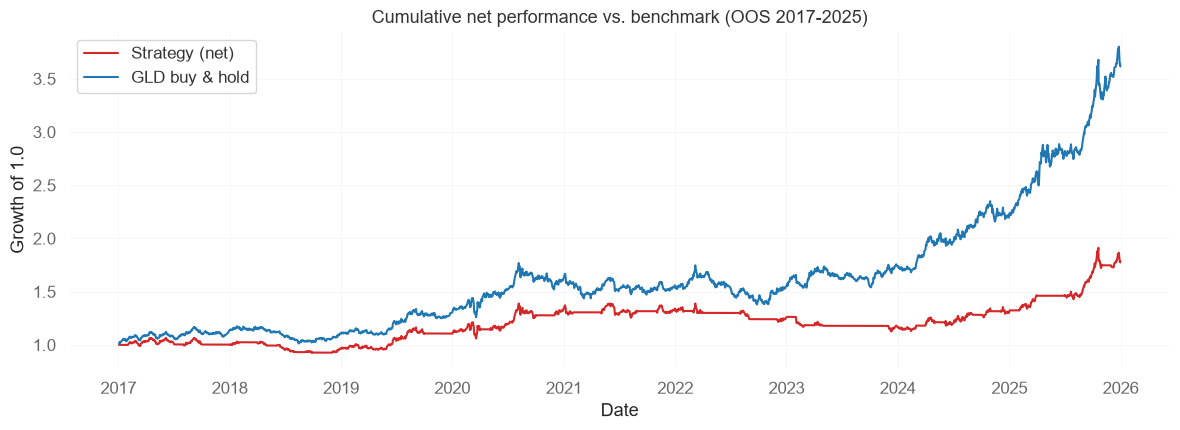

In [12]:
strat_ret_oos = result["daily_returns"].loc[OOS_START:OOS_END]
strat_eq_oos = (1.0 + strat_ret_oos).cumprod()
bench_ret_oos = merged["gld_adj_close"].pct_change().loc[OOS_START:OOS_END].fillna(0.0)
bench_eq_oos = (1.0 + bench_ret_oos).cumprod()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(strat_eq_oos.index, strat_eq_oos, color="#d62728", label="Strategy (net)")
ax.plot(bench_eq_oos.index, bench_eq_oos, color="#1f77b4", label="GLD buy & hold")
ax.set_title("Cumulative net performance vs. benchmark (OOS 2017-2025)")
ax.set_ylabel("Growth of 1.0"); ax.set_xlabel("Date"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

**Chart 2 — Drawdown** (underwater plot of the strategy's net OOS returns).

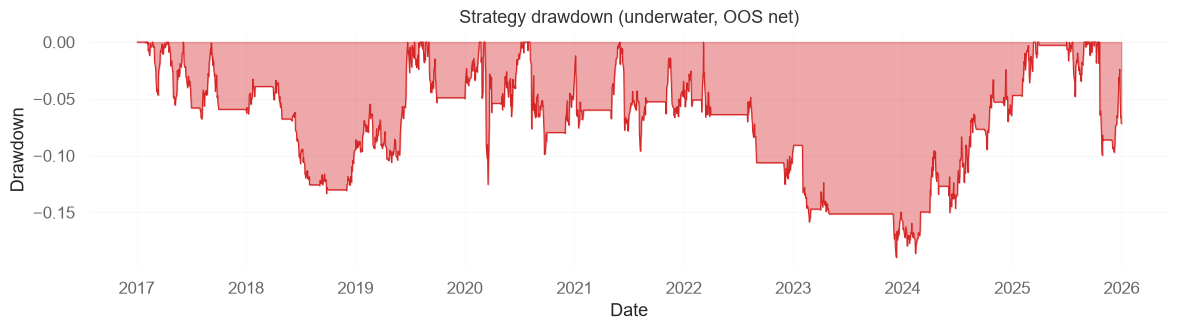

In [13]:
dd = strat_eq_oos / strat_eq_oos.cummax() - 1.0
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.fill_between(dd.index, dd.values, 0.0, color="#d62728", alpha=0.4)
ax.plot(dd.index, dd.values, color="#d62728", lw=0.8)
ax.set_title("Strategy drawdown (underwater, OOS net)")
ax.set_ylabel("Drawdown"); ax.set_xlabel("Date"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

**Chart 3 — Rolling Sharpe** (126-trading-day annualized Sharpe over the OOS period).

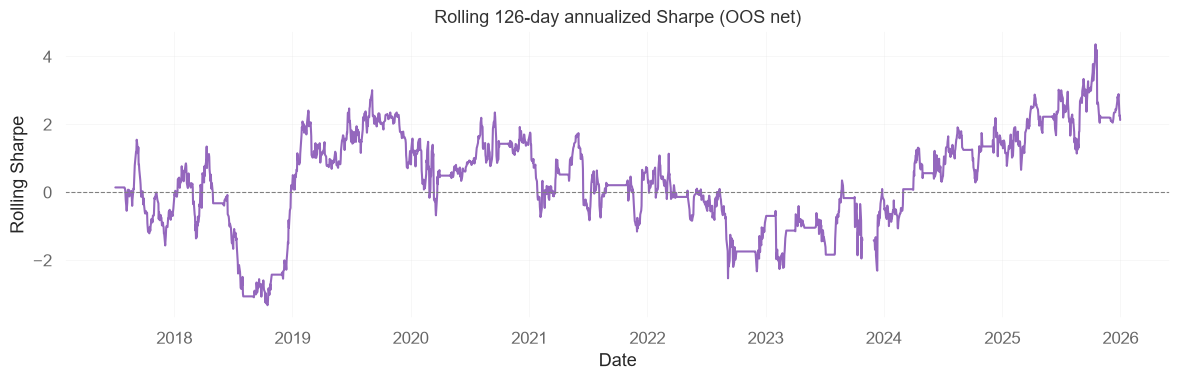

In [14]:
WIN = 126
roll_sharpe = (strat_ret_oos.rolling(WIN).mean()
               / strat_ret_oos.rolling(WIN).std(ddof=1)) * np.sqrt(252)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(roll_sharpe.index, roll_sharpe.values, color="#9467bd")
ax.axhline(0.0, color="gray", lw=0.8, ls="--")
ax.set_title("Rolling 126-day annualized Sharpe (OOS net)")
ax.set_ylabel("Rolling Sharpe"); ax.set_xlabel("Date"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

**Chart 4 — Signal / position over time** (long vs. flat across the OOS window).

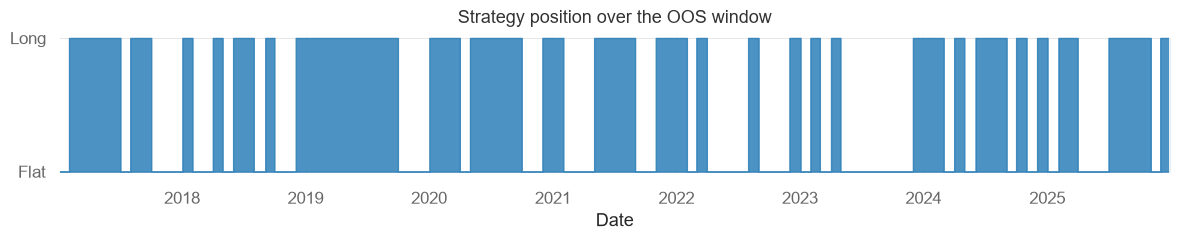

In [15]:
pos_oos = position.loc[OOS_START:OOS_END].fillna(0.0)
fig, ax = plt.subplots(figsize=(12, 2.6))
ax.fill_between(pos_oos.index, 0, pos_oos.values, step="post", color="#2c7fb8", alpha=0.85)
ax.set_ylim(-0.05, 1.05); ax.set_yticks([0, 1]); ax.set_yticklabels(["Flat", "Long"])
ax.set_title("Strategy position over the OOS window")
ax.set_xlabel("Date"); ax.margins(x=0); ax.grid(alpha=0.2, axis="x")
fig.tight_layout(); plt.show()

**Chart 5 — Diagnostic** (GLD price and DFII10 real yield on dual axes; green = strategy long).

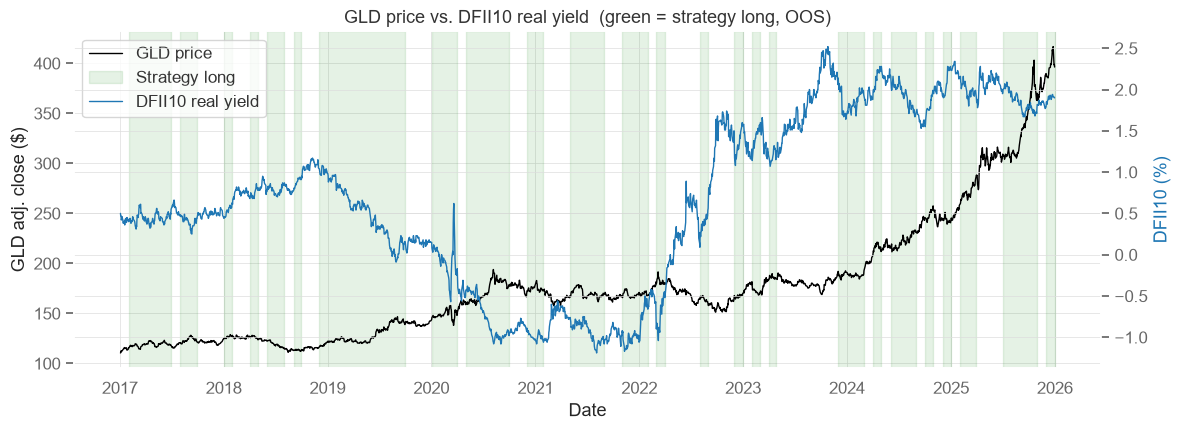

In [16]:
oos_slice = merged.loc[OOS_START:OOS_END]
long_mask = pos_oos.to_numpy() == 1.0
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(oos_slice.index, oos_slice["gld_adj_close"], color="black", lw=1.0, label="GLD price")
ax1.set_ylabel("GLD adj. close ($)"); ax1.set_xlabel("Date")
ax2 = ax1.twinx()
ax2.plot(oos_slice.index, oos_slice["dfii10_aligned"], color="#1f77b4", lw=1.0,
         label="DFII10 real yield")
ax2.set_ylabel("DFII10 (%)", color="#1f77b4")
ax1.fill_between(pos_oos.index, 0, 1, where=long_mask, transform=ax1.get_xaxis_transform(),
                 color="green", alpha=0.10, label="Strategy long")
ax1.set_title("GLD price vs. DFII10 real yield  (green = strategy long, OOS)")
l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, loc="upper left")
fig.tight_layout(); plt.show()

Finally, `report.py` assembles all of the above (verdict + charts + QuantStats tearsheet) into a single self-contained HTML file.

In [17]:
report_path = report.generate_report(merged)
print("Standalone HTML report written to:", report_path)

Standalone HTML report written to: D:\Jiheng\Claude Projects\gold_rate_carry\result\report.html


## 8. Conclusion

**Verdict: Monitor.**

The discount-rate mechanism is real and statistically supported — genuine, bootstrap-
significant edge over random timing in Regime 1 (2008–2021). It is not currently ready
to pursue: the 2022–2024 breakdown shows the mechanism adds no value once central-bank
reserve buying became gold's dominant marginal demand driver (European Central Bank,
2025; World Gold Council). Nor does it warrant outright rejection, given the demonstrated
historical edge and the specificity of the identified failure cause.

**Main limitation.** The 2022 regime boundary was chosen with this breakdown already
publicly documented, rather than discovered independently from the data — the regime
split confirms consistency with a known structural break, not new evidence that the
break occurred.

**Persistence.** Central-bank purchases have remained well above the pre-2022 average
through 2024–2025, suggesting this is not a short-lived reaction. Whether the
discount-rate channel reasserts itself, or central-bank demand becomes a lasting
structural feature of gold pricing, is the open question that should determine whether
this strategy is revisited.